# Proposition 4.1: oracle correction for the first robust IMF component

This experiment compares the first robust IMF component before and after the correction from Proposition 4.1. The target is the population component $S_1$, which minimizes the expected noisy contrast.

The proposition gives the first-order expansion

$$\widehat S_1-S_1 = F^{-1}\nabla + O(\lVert F^{-1}\nabla\rVert^2).$$

We therefore expect the uncorrected error to scale as $m_{\mathrm{eff}}^{-1/2}$ and the oracle-corrected error to scale as $m_{\mathrm{eff}}^{-1}$. Equivalently, corrected error should be quadratic in uncorrected error.


In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from numpy.lib.stride_tricks import sliding_window_view
from scipy.special import erf

SEED = 20260830
SIGMA = 0.25
H = 0.35
BANDWIDTH_FRACTION = 0.125
SAMPLE_SIZES = [128, 256, 512, 1024]
N_REPEATS = 40
REPEAT_BATCH_SIZE = 10

SQRT_2 = np.sqrt(2.0)
SQRT_2_OVER_PI = np.sqrt(2.0 / np.pi)
H_POP = np.sqrt(H**2 + SIGMA**2)

rng = np.random.default_rng(SEED)
pd.options.display.float_format = lambda value: f"{value:.4g}"


## Why the Gaussian case is useful

For $\varepsilon\sim N(0,\sigma^2)$ and $\psi_H(r)=\rho_H'(r)=\operatorname{erf}(r/(\sqrt{2}H))$, Gaussian convolution gives

$$\mathbb E\,\psi_H(a+\varepsilon)=\psi_{\sqrt{H^2+\sigma^2}}(a).$$

The population target and curvature are therefore available without simulation. For each local window, we compute

$$F_t=\sum_u w_{u,t}\,\rho_{H_{\rm pop}}''(X_u-S_{1,t}),$$

$$\nabla_t=\sum_u w_{u,t}\left[\psi_H(Y_u-S_{1,t})-\psi_{H_{\rm pop}}(X_u-S_{1,t})\right],$$

then apply the proposition's sign convention: $\widehat S_{1,t}^{\rm corr}=\widehat S_{1,t}-F_t^{-1}\nabla_t$. This is an oracle correction because it uses $X$, $S_1$, and the noise law.


## Experiment plan

- Use a smooth periodic signal and wrap boundaries, as in the existing IMF notebooks.
- Keep the physical bandwidth fixed while increasing the grid size. This raises the effective number of observations in each local fit.
- Compare RMSE and the median, over repeats, of the component-wise sup error.
- Estimate log-log slopes against $m_{\mathrm{eff}}=1/\sum_u w_u^2$. Slopes near $-1/2$ without correction and $-1$ with correction support the predicted orders.
- Also regress corrected RMSE on uncorrected RMSE. A slope near $2$ is the direct quadratic check.


In [2]:
def epanechnikov_weights(window_size: int) -> np.ndarray:
    if window_size % 2 == 0:
        raise ValueError("window_size must be odd")
    radius = window_size // 2
    if radius == 0:
        return np.array([1.0])
    offsets = np.arange(-radius, radius + 1)
    weights = 0.75 * np.maximum(0.0, 1.0 - np.abs(offsets / radius)) ** 2
    return weights / weights.sum()


def periodic_windows(values: np.ndarray, window_size: int) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    radius = window_size // 2
    pad_width = [(0, 0)] * values.ndim
    pad_width[-1] = (radius, radius)
    padded = np.pad(values, pad_width, mode="wrap")
    return sliding_window_view(padded, window_size, axis=-1)


def robust_score(residual: np.ndarray, scale: float) -> np.ndarray:
    return erf(np.asarray(residual) / (SQRT_2 * scale))


def robust_curvature(residual: np.ndarray, scale: float) -> np.ndarray:
    residual = np.asarray(residual)
    return SQRT_2_OVER_PI / scale * np.exp(-0.5 * (residual / scale) ** 2)


def fit_robust_windows(
    windows: np.ndarray, weights: np.ndarray, scale: float, max_iter: int = 40
) -> np.ndarray:
    """Solve the same local robust objective used by the robust IMF notebooks."""
    windows = np.asarray(windows, dtype=float)
    weights = np.asarray(weights, dtype=float)
    lo = windows.min(axis=-1)
    hi = windows.max(axis=-1)
    estimate = np.median(windows, axis=-1)

    for _ in range(max_iter):
        residual = windows - estimate[..., None]
        score = np.sum(weights * robust_score(residual, scale), axis=-1)
        curvature = np.sum(weights * robust_curvature(residual, scale), axis=-1)

        lo = np.where(score > 0.0, estimate, lo)
        hi = np.where(score <= 0.0, estimate, hi)
        newton = estimate + score / np.maximum(curvature, np.finfo(float).tiny)
        midpoint = 0.5 * (lo + hi)
        estimate = np.where((newton > lo) & (newton < hi), newton, midpoint)

    return estimate


def make_signal(n: int) -> tuple[np.ndarray, np.ndarray]:
    t = np.arange(n) / n
    signal = (
        0.55 * np.sin(2.0 * np.pi * t)
        + 0.20 * np.cos(6.0 * np.pi * t + 0.3)
        + 0.08 * np.sin(14.0 * np.pi * t)
    )
    return t, signal


def window_size_for(n: int) -> int:
    size = max(3, int(round(BANDWIDTH_FRACTION * n)))
    return size if size % 2 == 1 else size + 1


In [3]:
def population_quantities(signal: np.ndarray, window_size: int) -> dict[str, np.ndarray]:
    weights = epanechnikov_weights(window_size)
    clean_windows = periodic_windows(signal, window_size)
    target = fit_robust_windows(clean_windows, weights, H_POP)
    centered = clean_windows - target[:, None]
    expected_score = robust_score(centered, H_POP)
    curvature = np.sum(weights * robust_curvature(centered, H_POP), axis=-1)
    target_score = np.sum(weights * expected_score, axis=-1)
    if np.max(np.abs(target_score)) > 1e-10:
        raise RuntimeError("population robust fits did not converge")
    return {
        "weights": weights,
        "clean_windows": clean_windows,
        "target": target,
        "expected_score": expected_score,
        "curvature": curvature,
    }


def simulate_case(n: int, n_repeats: int, rng: np.random.Generator) -> tuple[dict, dict]:
    t, signal = make_signal(n)
    window_size = window_size_for(n)
    population = population_quantities(signal, window_size)
    weights = population["weights"]

    raw_errors = []
    corrected_errors = []
    first_example = None

    for start in range(0, n_repeats, REPEAT_BATCH_SIZE):
        batch_size = min(REPEAT_BATCH_SIZE, n_repeats - start)
        observations = signal + rng.normal(0.0, SIGMA, size=(batch_size, n))
        noisy_windows = periodic_windows(observations, window_size)
        estimate = fit_robust_windows(noisy_windows, weights, H)

        realized_score = robust_score(
            noisy_windows - population["target"][None, :, None], H
        )
        nabla = np.sum(
            weights
            * (realized_score - population["expected_score"][None, :, :]),
            axis=-1,
        )
        corrected = estimate - nabla / population["curvature"][None, :]

        raw_errors.append(estimate - population["target"][None, :])
        corrected_errors.append(corrected - population["target"][None, :])
        if first_example is None:
            first_example = {
                "t": t,
                "signal": signal,
                "observation": observations[0],
                "target": population["target"],
                "estimate": estimate[0],
                "corrected": corrected[0],
            }

    raw_error = np.concatenate(raw_errors, axis=0)
    corrected_error = np.concatenate(corrected_errors, axis=0)
    raw_sup = np.max(np.abs(raw_error), axis=1)
    corrected_sup = np.max(np.abs(corrected_error), axis=1)

    row = {
        "n": n,
        "window_size": window_size,
        "m_eff": 1.0 / np.sum(weights**2),
        "raw_rmse": np.sqrt(np.mean(raw_error**2)),
        "corrected_rmse": np.sqrt(np.mean(corrected_error**2)),
        "raw_median_sup": np.median(raw_sup),
        "corrected_median_sup": np.median(corrected_sup),
        "rmse_improvement": np.sqrt(np.mean(raw_error**2))
        / np.sqrt(np.mean(corrected_error**2)),
        "sup_improvement": np.median(raw_sup) / np.median(corrected_sup),
        "min_population_curvature": np.min(population["curvature"]),
    }
    return row, first_example


## Minimal check

Run one grid size first. The corrected curve should stay closer to the population target than the uncorrected robust component.


,n,window_size,m_eff,raw_rmse,corrected_rmse,raw_median_sup,corrected_median_sup,rmse_improvement,sup_improvement,min_population_curvature
0,256,33,17.73,0.05966,0.0042,0.2054,0.02172,14.21,9.456,1.755


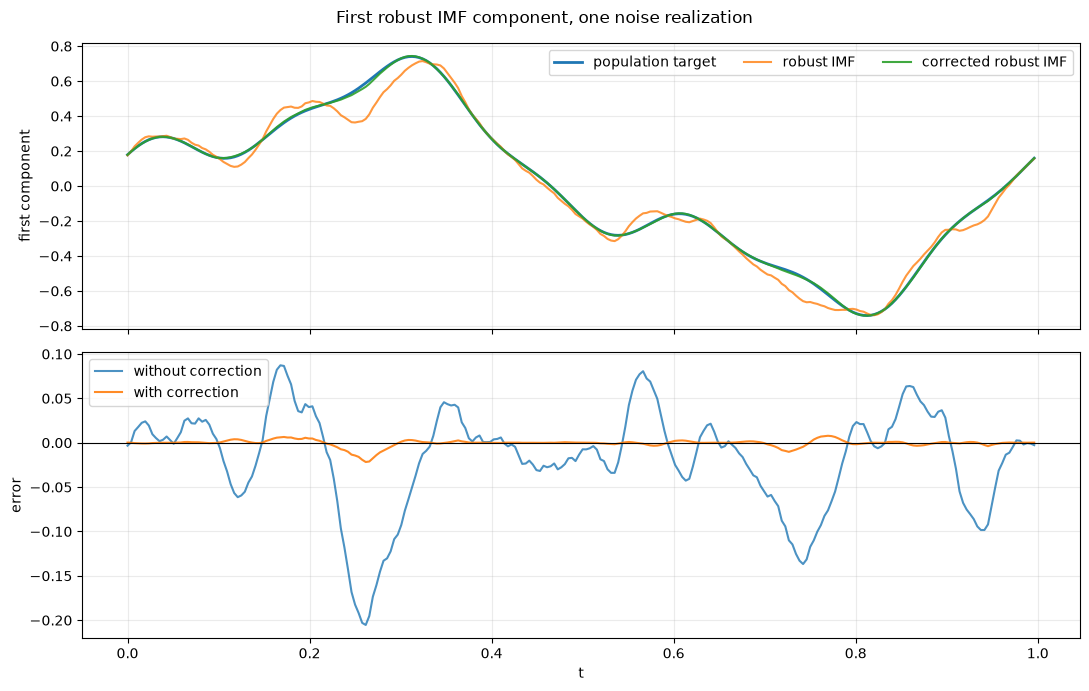

In [4]:
check_row, check_example = simulate_case(256, 1, np.random.default_rng(SEED))
display(pd.DataFrame([check_row]))

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(check_example["t"], check_example["target"], label="population target", lw=2)
axes[0].plot(check_example["t"], check_example["estimate"], label="robust IMF", alpha=0.8)
axes[0].plot(check_example["t"], check_example["corrected"], label="corrected robust IMF", alpha=0.9)
axes[0].set_ylabel("first component")
axes[0].legend(ncol=3)
axes[0].grid(alpha=0.25)

axes[1].plot(
    check_example["t"], check_example["estimate"] - check_example["target"],
    label="without correction", alpha=0.8,
)
axes[1].plot(
    check_example["t"], check_example["corrected"] - check_example["target"],
    label="with correction", alpha=0.9,
)
axes[1].axhline(0.0, color="black", lw=0.8)
axes[1].set(xlabel="t", ylabel="error")
axes[1].legend()
axes[1].grid(alpha=0.25)
fig.suptitle("First robust IMF component, one noise realization")
fig.tight_layout()


## Effective-sample-size sweep

Each row aggregates all time points and repeated noise draws. The two improvement columns report the error without correction divided by the error with correction.


In [5]:
rows = []
example = None
for n in SAMPLE_SIZES:
    row, current_example = simulate_case(n, N_REPEATS, rng)
    rows.append(row)
    if n == SAMPLE_SIZES[-1]:
        example = current_example

results = pd.DataFrame(rows)
results


,n,window_size,m_eff,raw_rmse,corrected_rmse,raw_median_sup,corrected_median_sup,rmse_improvement,sup_improvement,min_population_curvature
0,128,17,8.8,0.0824,0.007054,0.1966,0.02239,11.68,8.782,1.756
1,256,33,17.73,0.0598,0.00376,0.1398,0.01259,15.9,11.11,1.755
2,512,65,35.53,0.04169,0.001727,0.09602,0.006275,24.13,15.3,1.755
3,1024,129,71.1,0.03112,0.000914,0.07451,0.003233,34.05,23.05,1.755


In [6]:
def log_log_slope(x: np.ndarray, y: np.ndarray) -> float:
    return float(np.polyfit(np.log(x), np.log(y), deg=1)[0])


slopes = pd.Series({
    "RMSE without correction vs m_eff": log_log_slope(results["m_eff"], results["raw_rmse"]),
    "RMSE with correction vs m_eff": log_log_slope(results["m_eff"], results["corrected_rmse"]),
    "median sup without correction vs m_eff": log_log_slope(results["m_eff"], results["raw_median_sup"]),
    "median sup with correction vs m_eff": log_log_slope(results["m_eff"], results["corrected_median_sup"]),
    "corrected RMSE vs uncorrected RMSE": log_log_slope(results["raw_rmse"], results["corrected_rmse"]),
}, name="estimated slope")
slopes.to_frame()


,estimated slope
RMSE without correction vs m_eff,-0.4713
RMSE with correction vs m_eff,-0.9921
median sup without correction vs m_eff,-0.4721
median sup with correction vs m_eff,-0.9336
corrected RMSE vs uncorrected RMSE,2.105


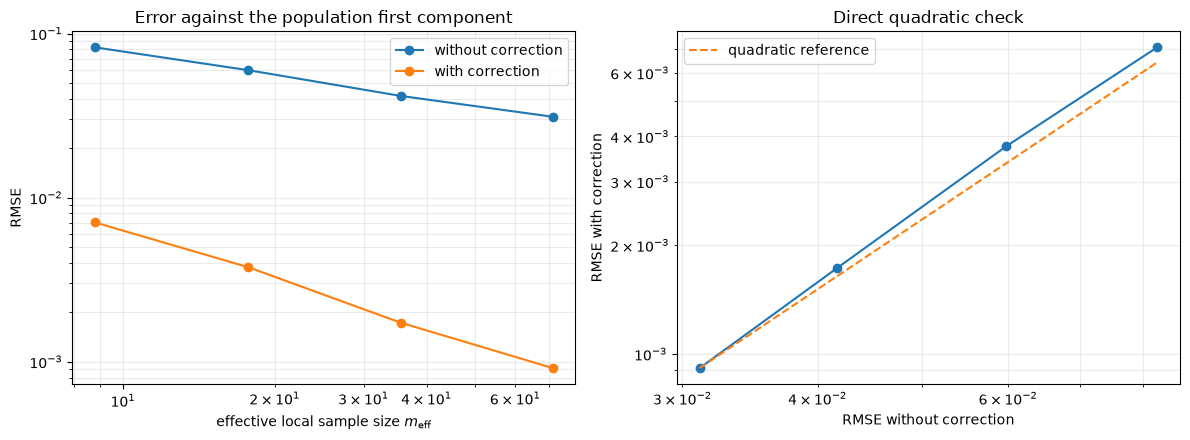

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].loglog(results["m_eff"], results["raw_rmse"], "o-", label="without correction")
axes[0].loglog(results["m_eff"], results["corrected_rmse"], "o-", label="with correction")
axes[0].set(xlabel=r"effective local sample size $m_{\rm eff}$", ylabel="RMSE")
axes[0].set_title("Error against the population first component")
axes[0].legend()
axes[0].grid(which="both", alpha=0.25)

axes[1].loglog(results["raw_rmse"], results["corrected_rmse"], "o-")
reference_x = np.array([results["raw_rmse"].min(), results["raw_rmse"].max()])
reference_c = results["corrected_rmse"].iloc[-1] / results["raw_rmse"].iloc[-1] ** 2
axes[1].loglog(reference_x, reference_c * reference_x**2, "--", label="quadratic reference")
axes[1].set(xlabel="RMSE without correction", ylabel="RMSE with correction")
axes[1].set_title("Direct quadratic check")
axes[1].legend()
axes[1].grid(which="both", alpha=0.25)

fig.tight_layout()


## Interpretation

With the fixed seed above, the uncorrected and corrected RMSE slopes are $-0.471$ and $-0.992$. The direct corrected-on-uncorrected slope is $2.105$. At the largest grid size, the correction cuts RMSE by a factor of $34$ and median sup error by a factor of $23$. These results match the first-order and second-order rates in Proposition 4.1.

The useful comparison is between estimated slopes, not only the error ratio at one grid size. Finite samples, the supremum over overlapping windows, and numerical optimization can move the slopes away from their ideal values.

This notebook tests the first robust IMF stage and uses the proposition's population target. Extending the same correction through later recursive stages would require tracking how each corrected component changes the residual passed to the next stage.
